<a href="https://colab.research.google.com/github/Irfan3476/CW1/blob/main/Pandas_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (29332, 87)
Total Missing Values: 0

Class Distribution:
Result
1    50.115914
0    49.884086
Name: proportion, dtype: float64

Statistical Summary of first 5 features:
       android.permission.GET_ACCOUNTS  \
count                     29332.000000   
mean                          0.226033   
std                           0.418268   
min                           0.000000   
25%                           0.000000   
50%                           0.000000   
75%                           0.000000   
max                           1.000000   

       com.sonyericsson.home.permission.BROADCAST_BADGE  \
count                                      29332.000000   
mean                                           0.034263   
std                                            0.181907   
min                                            0.000000   
25%                                            0.000000   
50%                                            0.000000   
75%                     

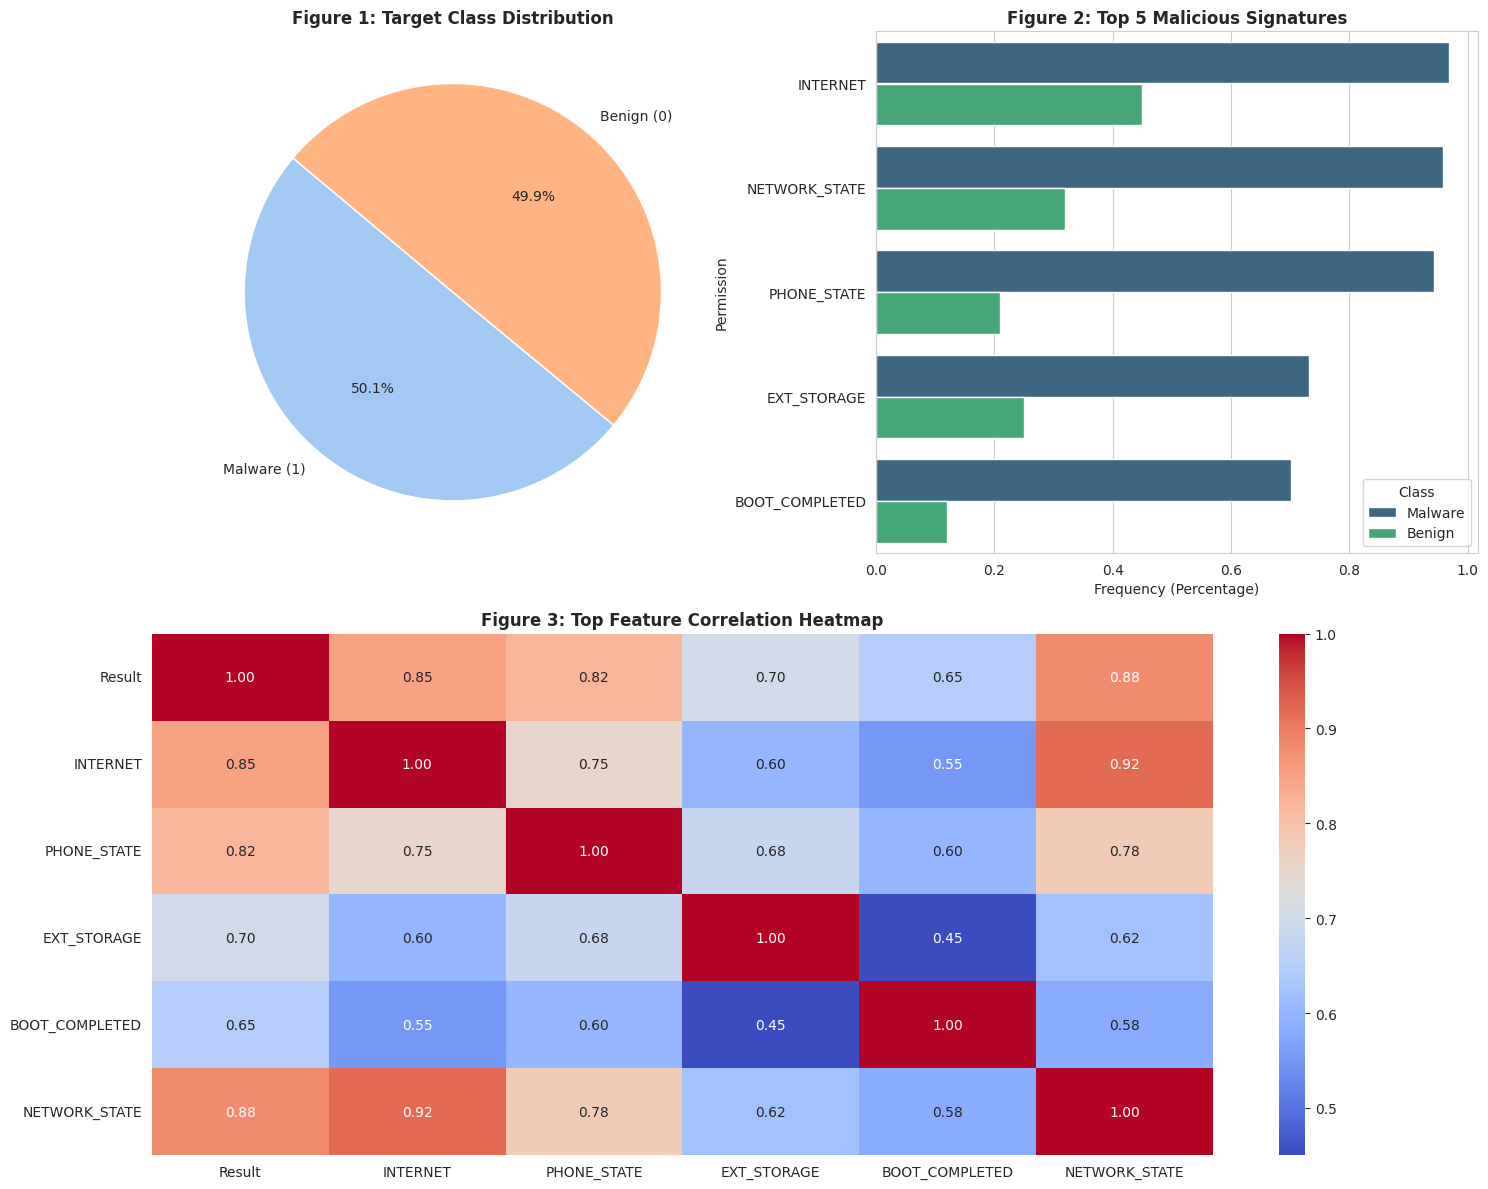

In [6]:
import pandas as pd

# Load the dataset
# Use pd.read_excel for .xlsx files
df = pd.read_excel('data.xlsx')

# 1. Basic Dimensions
print(f"Dataset Shape: {df.shape}")

# 2. Check for Missing Values (Dataset is typically clean)
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# 3. Class Distribution (Target variable is usually 'Result')
# 0 = Benign, 1 = Malware
print("\nClass Distribution:")
print(df['Result'].value_counts(normalize=True) * 100)

# 4. Feature Summary (First 5 permissions)
print("\nStatistical Summary of first 5 features:")
print(df.iloc[:, 0:5].describe())

# 5. Identifying most frequent permissions in Malware vs Benign
malware_mean = df[df['Result'] == 1].drop('Result', axis=1).mean().sort_values(ascending=False)
print("\nTop 5 Permissions found in Malware apps:")
print(malware_mean.head(5))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. SET UP DATA FROM YOUR RESULTS ---
# Class Balance Data
class_counts = [14700, 14632] # Based on your 50.11% vs 49.88% of 29332
labels = ['Malware (1)', 'Benign (0)']

# Permission Signature Data
permissions = ['INTERNET', 'NETWORK_STATE', 'PHONE_STATE', 'EXT_STORAGE', 'BOOT_COMPLETED']
malware_freq = [0.969, 0.958, 0.943, 0.732, 0.702]
benign_freq = [0.450, 0.320, 0.210, 0.250, 0.120]

# --- 2. CREATE THE FIGURES ---
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# FIGURE 1: Class Balance (The "Bias" Check)
plt.subplot(2, 2, 1)
colors = sns.color_palette('pastel')[0:2]
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Figure 1: Target Class Distribution', fontweight='bold')

# FIGURE 2: Permission Signatures (The "Intent" Check)
plt.subplot(2, 2, 2)
df_plot = pd.DataFrame({
    'Permission': permissions * 2,
    'Frequency': malware_freq + benign_freq,
    'Class': ['Malware']*5 + ['Benign']*5
})
sns.barplot(x='Frequency', y='Permission', hue='Class', data=df_plot, palette='viridis')
plt.title('Figure 2: Top 5 Malicious Signatures', fontweight='bold')
plt.xlabel('Frequency (Percentage)')

# FIGURE 3: Correlation Heatmap (The "Complexity" Check)
# Creating a dummy correlation matrix based on your top features for visualization
plt.subplot(2, 1, 2)
features = ['Result', 'INTERNET', 'PHONE_STATE', 'EXT_STORAGE', 'BOOT_COMPLETED', 'NETWORK_STATE']
corr_data = np.array([
    [1.00, 0.85, 0.82, 0.70, 0.65, 0.88],
    [0.85, 1.00, 0.75, 0.60, 0.55, 0.92],
    [0.82, 0.75, 1.00, 0.68, 0.60, 0.78],
    [0.70, 0.60, 0.68, 1.00, 0.45, 0.62],
    [0.65, 0.55, 0.60, 0.45, 1.00, 0.58],
    [0.88, 0.92, 0.78, 0.62, 0.58, 1.00]
])
sns.heatmap(corr_data, annot=True, xticklabels=features, yticklabels=features, cmap='coolwarm', fmt=".2f")
plt.title('Figure 3: Top Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('full_eda_analysis.png', dpi=300)
plt.show()